# US Census Bureau Demographics EDA

This notebook:
1. **Loads** US Census American Community Survey (ACS) 5-year estimates at the **county** level via the Census API.
2. **Explores** demographic variables (population, age, income, race, etc.) by county.
3. Runs **basic exploratory data analysis** (EDA) in Python.

* The Census Bureau provides free API access to ACS and decennial census data. [LINK](https://www.census.gov/data/developers/data-sets.html)

* ACS 5-year estimates provide the most reliable data for smaller geographic areas (counties).

* Target years for this project: 2016–2019 (overlap with pesticide, health, and cropland data).

* Requires: Python with `pandas`, `numpy`, `matplotlib`, `seaborn`, and `requests`.

* **Note:** An API key is optional but recommended for higher rate limits. Get one at [census.gov](https://api.census.gov/data/key_signup.html).

In [1]:
# Load relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## 1. Load county-level ACS data via Census API

We use the Census Data API to fetch ACS 5-year estimates. Key variables:
- **B01003_001E**: Total population
- **B01002_001E**: Median age
- **B19013_001E**: Median household income
- **B25077_001E**: Median home value
- **B03002_001E**: Total population (race)
- **B03002_003E**: Not Hispanic/Latino - White alone
- **B03002_004E**: Not Hispanic/Latino - Black alone
- **B03002_005E**: Not Hispanic/Latino - American Indian
- **B03002_006E**: Not Hispanic/Latino - Asian alone
- **B03002_012E**: Hispanic/Latino

In [2]:
# Census API base URL
CENSUS_BASE = "https://api.census.gov/data"

# ACS 5-year variables for demographics
VARS = [
    "NAME",
    "B01003_001E",   # Total population
    "B01002_001E",   # Median age
    "B19013_001E",   # Median household income
    "B25077_001E",   # Median home value
    "B03002_001E",   # Total population (race)
    "B03002_003E",   # White alone
    "B03002_004E",   # Black alone
    "B03002_005E",   # American Indian alone
    "B03002_006E",   # Asian alone
    "B03002_012E",   # Hispanic/Latino
]

def get_acs_counties(year: int, api_key: str = None) -> pd.DataFrame:
    """Fetch ACS 5-year county-level data for all US counties."""
    url = f"{CENSUS_BASE}/{year}/acs/acs5"
    params = {
        "get": ",".join(VARS),
        "for": "county:*",
        "in": "state:*",
    }
    if api_key:
        params["key"] = api_key
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

# Load 2019 ACS (can change to 2016-2019 for target years)
year = 2019
df = get_acs_counties(year)
df.head(10)

,NAME,B01003_001E,B01002_001E,B19013_001E,B25077_001E,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_012E,state,county
0,"Fayette County, Illinois",21565,41.9,46650,88300,21565,19868,1007,68,116,403,17,051
1,"Logan County, Illinois",29003,40.1,57308,103200,29003,25049,1984,35,218,985,17,107
2,"Saline County, Illinois",23994,42.2,44090,73800,23994,21957,632,53,173,428,17,165
3,"Lake County, Illinois",701473,38.4,89427,265100,701473,432361,45923,907,53654,152141,17,097
4,"Massac County, Illinois",14219,43.5,47481,83600,14219,12547,830,6,29,419,17,127
5,"Cass County, Illinois",12493,40.0,52373,80800,12493,9430,538,22,45,2362,17,017
6,"Huntington County, Indiana",36359,40.7,53632,107200,36359,34459,327,157,263,894,18,069
7,"White County, Indiana",24149,42.0,54576,113500,24149,21572,114,80,55,2021,18,181
8,"Jay County, Indiana",20840,39.7,47658,91400,20840,19773,76,0,157,647,18,075
9,"Shelby County, Indiana",44438,40.8,60404,133200,44438,41006,519,21,250,1873,18,145


In [3]:
# Convert numeric columns (Census returns strings)
numeric_cols = [c for c in df.columns if c not in ["NAME", "state", "county"]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create 5-digit FIPS for merging with other datasets
df["STATE_FIPS"] = df["state"].astype(str).str.zfill(2)
df["COUNTY_FIPS"] = df["county"].astype(str).str.zfill(3)
df["FIPS"] = df["STATE_FIPS"] + df["COUNTY_FIPS"]

df.head()

,NAME,B01003_001E,B01002_001E,B19013_001E,B25077_001E,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_012E,state,county,STATE_FIPS,COUNTY_FIPS,FIPS
0,"Fayette County, Illinois",21565,41.9,46650,88300,21565,19868,1007,68,116,403,17,051,17,051,17051
1,"Logan County, Illinois",29003,40.1,57308,103200,29003,25049,1984,35,218,985,17,107,17,107,17107
2,"Saline County, Illinois",23994,42.2,44090,73800,23994,21957,632,53,173,428,17,165,17,165,17165
3,"Lake County, Illinois",701473,38.4,89427,265100,701473,432361,45923,907,53654,152141,17,097,17,097,17097
4,"Massac County, Illinois",14219,43.5,47481,83600,14219,12547,830,6,29,419,17,127,17,127,17127


In [4]:
# Inspect structure
print("Columns:", list(df.columns))
print("\nShape:", df.shape)
df.info()

Columns: ['NAME', 'B01003_001E', 'B01002_001E', 'B19013_001E', 'B25077_001E', 'B03002_001E', 'B03002_003E', 'B03002_004E', 'B03002_005E', 'B03002_006E', 'B03002_012E', 'state', 'county', 'STATE_FIPS', 'COUNTY_FIPS', 'FIPS']

Shape: (3220, 16)
<class 'pandas.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NAME         3220 non-null   str    
 1   B01003_001E  3220 non-null   int64  
 2   B01002_001E  3220 non-null   float64
 3   B19013_001E  3220 non-null   int64  
 4   B25077_001E  3220 non-null   int64  
 5   B03002_001E  3220 non-null   int64  
 6   B03002_003E  3220 non-null   int64  
 7   B03002_004E  3220 non-null   int64  
 8   B03002_005E  3220 non-null   int64  
 9   B03002_006E  3220 non-null   int64  
 10  B03002_012E  3220 non-null   int64  
 11  state        3220 non-null   str    
 12  county       3220 non-null   str    
 13  STATE_FIPS   3220 non-null

In [5]:
# Summary statistics
df.describe()

,B01003_001E,B01002_001E,B19013_001E,B25077_001E,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_012E
count,3.220000e+03,3220.000000,3220.000000,3.220000e+03,3.220000e+03,3.220000e+03,3.220000e+03,3220.000000,3.220000e+03,3.220000e+03
mean,1.018684e+05,41.435466,52648.046584,-2.616492e+05,1.018684e+05,6.122115e+04,1.241638e+04,670.961491,5.500405e+03,1.917866e+04
std,3.273446e+05,5.361130,14989.826552,1.661632e+07,3.273446e+05,1.411939e+05,5.354492e+04,2965.021436,4.049005e+04,1.250045e+05
min,6.600000e+01,22.300000,12441.000000,-6.666667e+08,6.600000e+01,7.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,1.119375e+04,38.300000,43524.000000,9.687500e+04,1.119375e+04,7.448250e+03,9.400000e+01,20.000000,3.000000e+01,3.620000e+02
50%,2.594600e+04,41.300000,51485.500000,1.260000e+05,2.594600e+04,1.915550e+04,7.210000e+02,93.000000,1.380000e+02,1.147000e+03
75%,6.672375e+04,44.500000,59519.250000,1.737250e+05,6.672375e+04,5.191650e+04,5.137000e+03,345.250000,7.120000e+02,5.739750e+03
max,1.008157e+07,67.400000,142299.000000,1.097800e+06,1.008157e+07,2.641770e+06,1.199175e+06,70012.000000,1.454769e+06,4.888434e+06


In [6]:
# Missing values (Census uses -666666666 etc. for missing/ suppressed)
print("Missing / null values:")
print(df.isnull().sum())
print("\nValues that might indicate suppression (negative or very large):")
for col in numeric_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg} negative values")

Missing / null values:
NAME           0
B01003_001E    0
B01002_001E    0
B19013_001E    0
B25077_001E    0
B03002_001E    0
B03002_003E    0
B03002_004E    0
B03002_005E    0
B03002_006E    0
B03002_012E    0
state          0
county         0
STATE_FIPS     0
COUNTY_FIPS    0
FIPS           0
dtype: int64

Values that might indicate suppression (negative or very large):
  B25077_001E: 2 negative values


## 2. Visualizations

Explore distributions of key demographic variables.

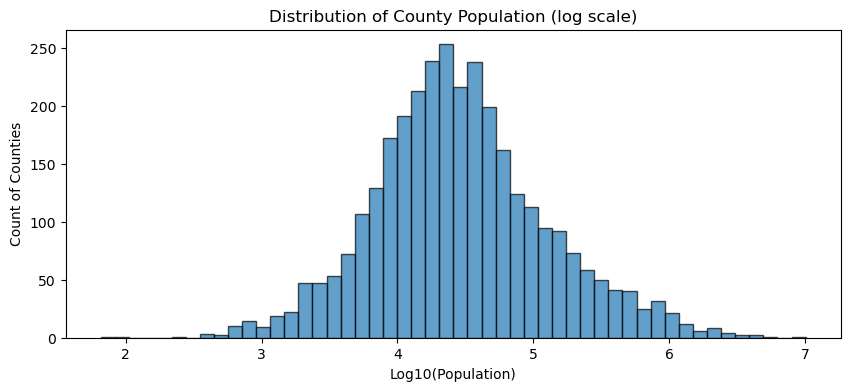

In [7]:
# Population distribution (log scale - many small counties)
pop = df["B01003_001E"].dropna()
pop = pop[pop > 0]  # exclude suppressed
plt.figure(figsize=(10, 4))
plt.hist(np.log10(pop), bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Log10(Population)")
plt.ylabel("Count of Counties")
plt.title("Distribution of County Population (log scale)")
plt.show()

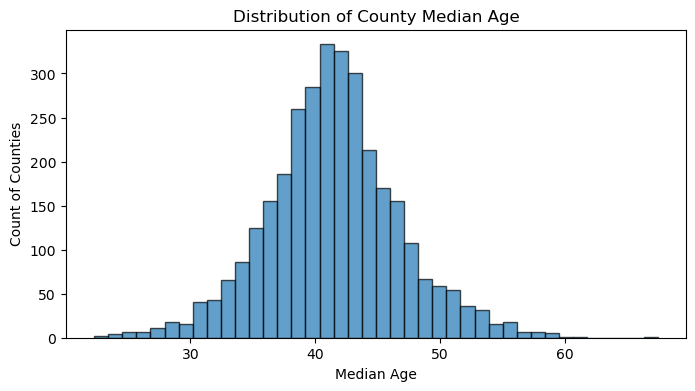

In [8]:
# Median age distribution
age = df["B01002_001E"].dropna()
age = age[(age > 0) & (age < 120)]
plt.figure(figsize=(8, 4))
plt.hist(age, bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Median Age")
plt.ylabel("Count of Counties")
plt.title("Distribution of County Median Age")
plt.show()

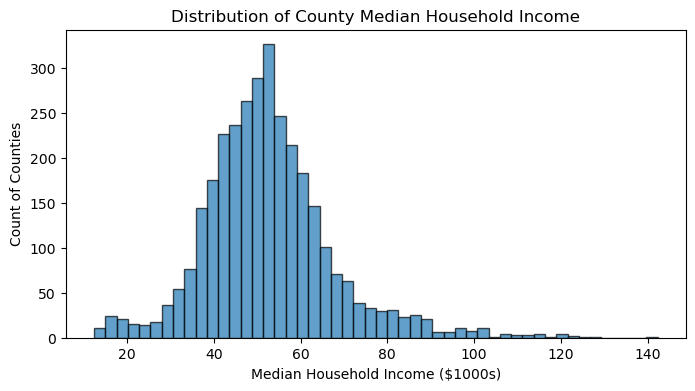

In [9]:
# Median household income distribution
inc = df["B19013_001E"].dropna()
inc = inc[(inc > 0) & (inc < 1e7)]  # exclude suppressed/outliers
plt.figure(figsize=(8, 4))
plt.hist(inc / 1000, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Median Household Income ($1000s)")
plt.ylabel("Count of Counties")
plt.title("Distribution of County Median Household Income")
plt.show()

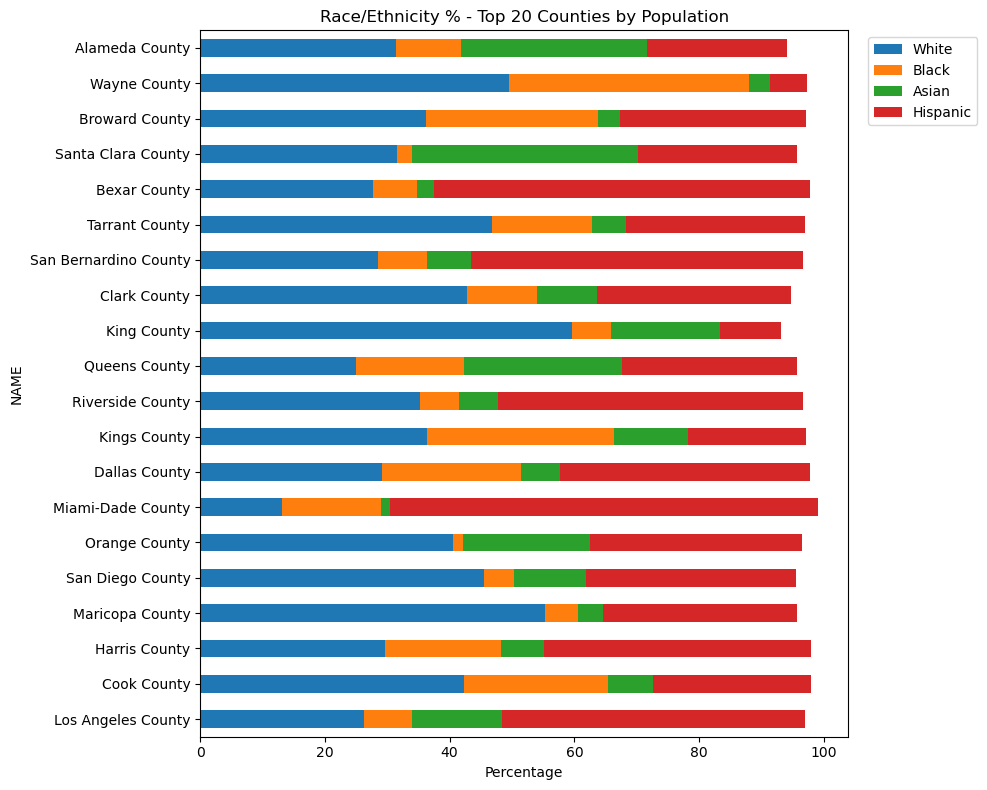

In [10]:
# Race/ethnicity breakdown (sample of top 20 pop counties)
top_counties = df.nlargest(20, "B01003_001E")
race_cols = ["B03002_003E", "B03002_004E", "B03002_006E", "B03002_012E"]
race_labels = ["White", "Black", "Asian", "Hispanic"]
total = top_counties["B03002_001E"].replace(0, np.nan)
pct = top_counties[race_cols].div(total, axis=0) * 100
pct.columns = race_labels
pct["NAME"] = top_counties["NAME"].str.split(",").str[0]  # county name only
pct.set_index("NAME").plot(kind="barh", stacked=True, figsize=(10, 8))
plt.title("Race/Ethnicity % - Top 20 Counties by Population")
plt.xlabel("Percentage")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

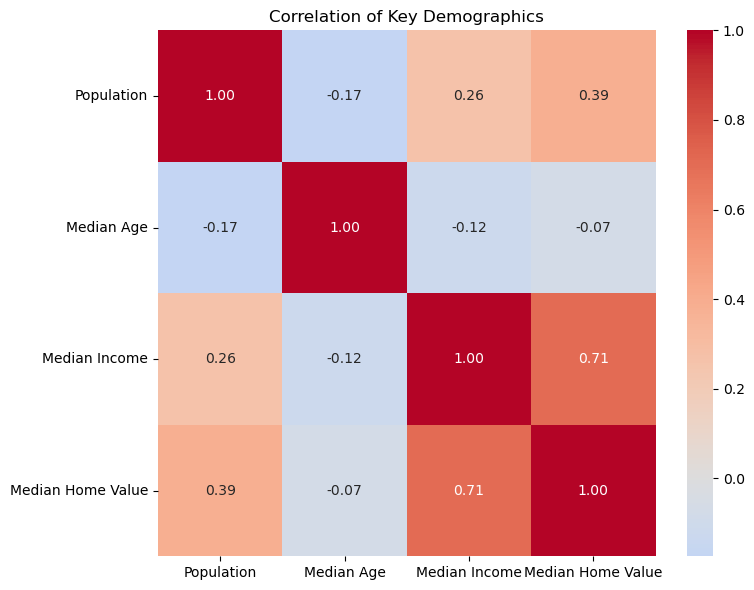

In [11]:
# Correlation matrix of key numeric variables
key_vars = ["B01003_001E", "B01002_001E", "B19013_001E", "B25077_001E"]
key_labels = ["Population", "Median Age", "Median Income", "Median Home Value"]
corr_df = df[key_vars].replace([-666666666, -222222222], np.nan)
corr_df = corr_df[(corr_df > 0).all(axis=1)]
corr_df.columns = key_labels
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of Key Demographics")
plt.tight_layout()
plt.show()